# 04A — Monthly Aggregation & Coverage-Aware Grids (Checkpoint 4A)

**Monthly exploratory proton-flux aggregation** for **NOAA-19, January 2024**, channel
`mep_omni_flux_p1` (differential proton flux ~25 MeV, `#/cm2-s-str-MeV`), over the South America /
South Atlantic sector. Produces a **coverage-aware gridded product** — a foundation for later
threshold sensitivity analysis.

**Executed on real data — outputs are real, not fabricated.**

> **Strict scope.** Not a final SAA shape or center, **not** dose, **not** health risk, **not** a
> discovery, **not** a satellite-danger estimate, and **not** a replacement for professional
> radiation models. Blank grid cells mean *missing or insufficient data* (never interpolated).

In [1]:
import os, sys, pathlib, copy
import numpy as np, pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

cwd = pathlib.Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(ROOT / "src"))

from saa.aggregate import load_range, build_grid_table, add_coverage_mask
from saa.grid_flux import prepare_region, grid_statistics, DEFAULT_LAT_RANGE, DEFAULT_LON_RANGE
from saa.plot_maps import plot_heatmap

RAW_DIR   = ROOT / "data" / "raw"
PROC_DIR  = ROOT / "data" / "processed"
TBL_DIR   = ROOT / "outputs" / "tables"
FIG_DIR   = ROOT / "outputs" / "figures"
for d in (PROC_DIR, TBL_DIR, FIG_DIR): d.mkdir(parents=True, exist_ok=True)

SAT, CHANNEL = "noaa19", "mep_omni_flux_p1"
START, END = "2024-01-01", "2024-01-31"
LAT_RANGE, LON_RANGE = DEFAULT_LAT_RANGE, DEFAULT_LON_RANGE   # (-70,20), (-100,20)
# Coverage thresholds (justified below from the observed monthly distribution):
THRESH_5DEG = 30
THRESH_2DEG = 30
print("region: lat", LAT_RANGE, "lon", LON_RANGE, "| channel:", CHANNEL)

region: lat (-70.0, 20.0) lon (-100.0, 20.0) | channel: mep_omni_flux_p1


## Step 1 — Load the month (download missing days; tolerate failures)

In [2]:
rl = load_range(START, END, satellite=SAT, raw_dir=str(RAW_DIR), channel=CHANNEL)
print("expected days :", rl.n_expected)
print("loaded days   :", rl.n_loaded)
print("missing days  :", [str(d) for d in rl.missing_dates] or "none")
print("month complete:", rl.complete)
print("total rows (all loaded days):", len(rl.df))

expected days : 31
loaded days   : 31
missing days  : none
month complete: True
total rows (all loaded days): 1206770


## Step 2 — Longitude conversion, region filter, calibration filter, save regional subset

`[0,360) -> [-180,180)`, region lat -70..+20 / lon -100..+20, drop `mep_IFC_on == 1`
(keep `-1`, uninterpreted).

In [3]:
region, counts = prepare_region(rl.df, LAT_RANGE, LON_RANGE)
print("rows BEFORE geographic filter:", counts["n_total"])
print("rows AFTER  geographic filter:", counts["n_after_geo"])
print("rows BEFORE mep_IFC_on filter:", counts["n_after_geo"])
print("rows AFTER  mep_IFC_on filter:", counts["n_after_ifc"])
print("  dropped mep_IFC_on == 1 :", counts["n_ifc_on_dropped"])
print("  kept    mep_IFC_on == -1:", counts["n_ifc_minus1"], "(uninterpreted)")
print()
print("longitude conversion check: lon180 in [%.3f, %.3f] (must be within [-180,180) and [-100,20])"
      % (region["lon180"].min(), region["lon180"].max()))
print()
print("flux summary (region): min=%.4f max=%.4f mean=%.4f  >0=%d  zeros=%d"
      % (region[CHANNEL].min(), region[CHANNEL].max(), region[CHANNEL].mean(),
         int((region[CHANNEL] > 0).sum()), int((region[CHANNEL] == 0).sum())))
display(region[[CHANNEL]].describe())

REGION_PARQUET = PROC_DIR / "noaa19_2024-01_mep_omni_flux_p1_region.parquet"
region.to_parquet(REGION_PARQUET, index=False, compression="zstd")
print("saved regional subset:", REGION_PARQUET.name, "(%d rows, %d bytes, zstd)"
      % (len(region), os.path.getsize(REGION_PARQUET)))

rows BEFORE geographic filter: 1206770
rows AFTER  geographic filter: 205153
rows BEFORE mep_IFC_on filter: 205153
rows AFTER  mep_IFC_on filter: 205153
  dropped mep_IFC_on == 1 : 0
  kept    mep_IFC_on == -1: 192334 (uninterpreted)

longitude conversion check: lon180 in [-100.000, 20.000] (must be within [-180,180) and [-100,20])

flux summary (region): min=0.0000 max=147.5573 mean=3.3715  >0=200274  zeros=4879


,mep_omni_flux_p1
count,205153.000000
mean,3.371501
std,6.896139
min,0.000000
25%,0.019900
50%,0.139400
75%,2.531700
max,147.557297


saved regional subset: noaa19_2024-01_mep_omni_flux_p1_region.parquet (205153 rows, 3639640 bytes, zstd)


## Step 3 — Coverage-aware grid tables (5° and 2°)

In [4]:
t5 = build_grid_table(region, CHANNEL, 5.0, 5.0, LAT_RANGE, LON_RANGE)
t2 = build_grid_table(region, CHANNEL, 2.0, 2.0, LAT_RANGE, LON_RANGE)

for label, t, thr in [("5deg", t5, THRESH_5DEG), ("2deg", t2, THRESH_2DEG)]:
    sc = t["sample_count"]
    print("=== %s grid: %d populated cells ===" % (label, len(t)))
    print("  sample_count: min=%d  q10=%d  median=%d  q90=%d  max=%d"
          % (sc.min(), int(sc.quantile(.1)), int(sc.median()), int(sc.quantile(.9)), sc.max()))
    print("  cells with sample_count >= %d : %d (%.1f%%)" % (thr, int((sc >= thr).sum()), 100*(sc >= thr).mean()))
    print()

# Coverage masks (justification: see printed distribution above and docs/research_notes.md CP4A)
t5 = add_coverage_mask(t5, THRESH_5DEG, "enough_samples_5deg")
t2 = add_coverage_mask(t2, THRESH_2DEG, "enough_samples_2deg")
print("5deg cells passing coverage (>= %d): %d / %d" % (THRESH_5DEG, int(t5["enough_samples_5deg"].sum()), len(t5)))
print("2deg cells passing coverage (>= %d): %d / %d" % (THRESH_2DEG, int(t2["enough_samples_2deg"].sum()), len(t2)))

T5 = TBL_DIR / "cp4a_noaa19_2024-01_grid_5deg.parquet"
T2 = TBL_DIR / "cp4a_noaa19_2024-01_grid_2deg.parquet"
t5.to_parquet(T5, index=False); t2.to_parquet(T2, index=False)
print("saved:", T5.name, "(%d bytes)" % os.path.getsize(T5), "|", T2.name, "(%d bytes)" % os.path.getsize(T2))
display(t5.head())

=== 5deg grid: 432 populated cells ===
  sample_count: min=276  q10=400  median=477  q90=542  max=599
  cells with sample_count >= 30 : 432 (100.0%)

=== 2deg grid: 2700 populated cells ===
  sample_count: min=16  q10=51  median=76  q90=99  max=127
  cells with sample_count >= 30 : 2685 (99.4%)

5deg cells passing coverage (>= 30): 432 / 432
2deg cells passing coverage (>= 30): 2685 / 2700


saved: cp4a_noaa19_2024-01_grid_5deg.parquet (19550 bytes) | cp4a_noaa19_2024-01_grid_2deg.parquet (77119 bytes)


,lat_bin_center,lon_bin_center,mean_flux,median_flux,sample_count,positive_sample_count,min_flux,max_flux,enough_samples_5deg
0,-67.5,-97.5,0.028832,0.0206,599,581,0.0,0.1952,True
1,-67.5,-92.5,0.028815,0.0213,515,499,0.0,0.1716,True
2,-67.5,-87.5,0.026722,0.0182,482,460,0.0,0.1719,True
3,-67.5,-82.5,0.029097,0.0216,506,489,0.0,0.1469,True
4,-67.5,-77.5,0.027175,0.0187,533,515,0.0,0.1956,True


## Step 4 — Monthly figures (mean / median / sample-count at 5° and 2°)

Flux maps use a **log10 color scale**. On the **mean/median** maps, **blank cells = no data OR
below the coverage threshold (insufficient samples)** — values are never interpolated. The
**sample-count** maps show every populated cell (linear scale).

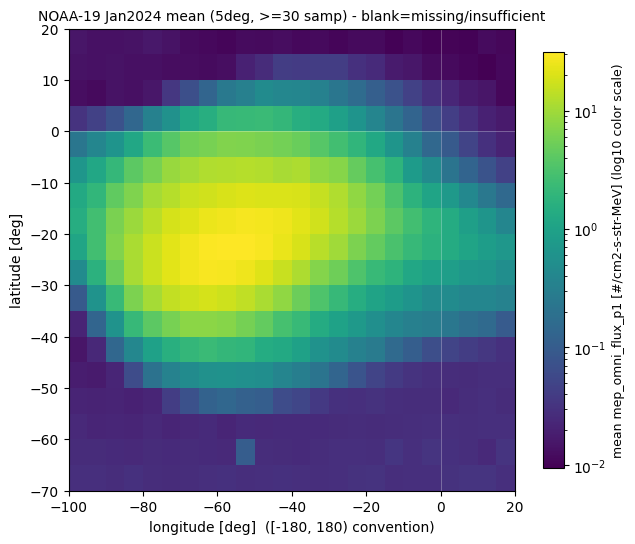

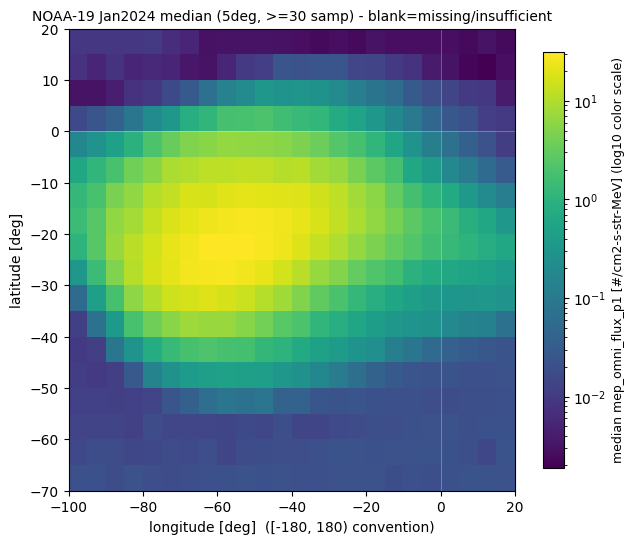

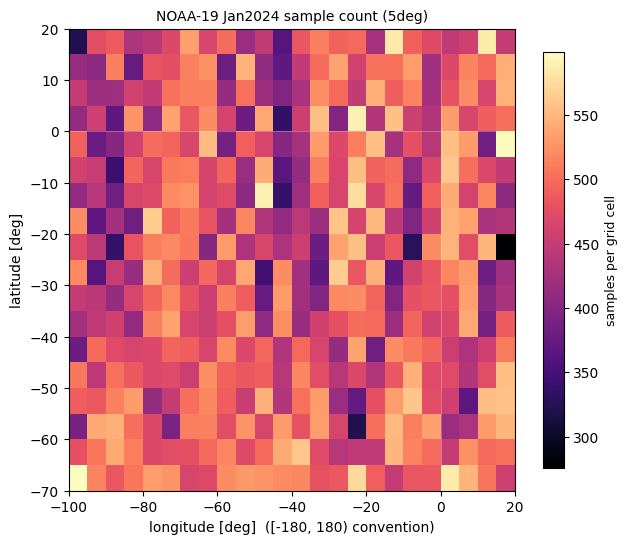

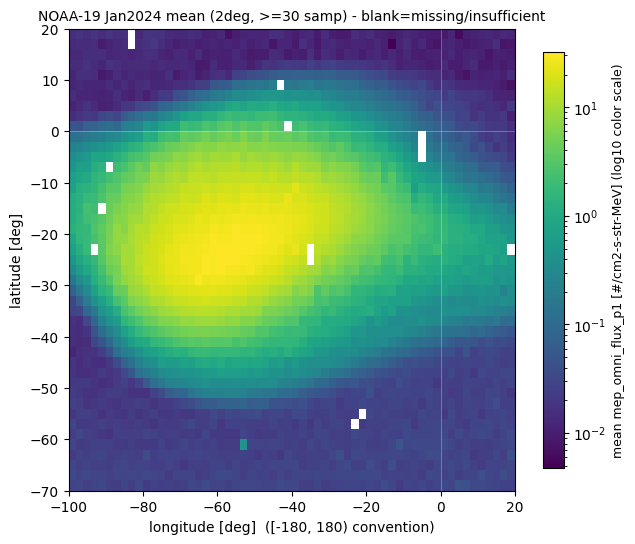

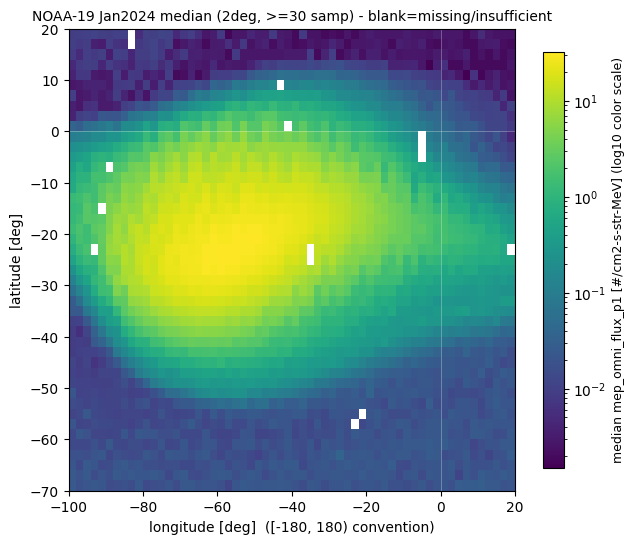

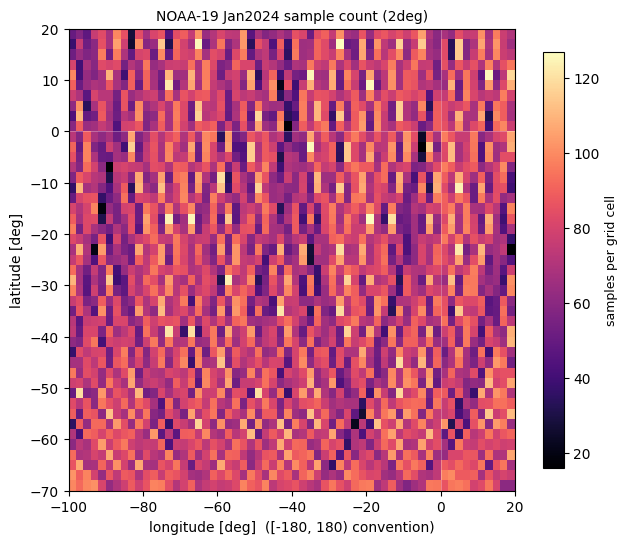

saved 6 figures to /home/fellipe/Projects/Active/saa-poes-mapping/outputs/figures


In [5]:
g5 = grid_statistics(region, CHANNEL, 5.0, 5.0, LAT_RANGE, LON_RANGE)
g2 = grid_statistics(region, CHANNEL, 2.0, 2.0, LAT_RANGE, LON_RANGE)

def coverage_masked(g, thr):
    gm = copy.deepcopy(g)
    gm.mean = gm.mean.copy(); gm.median = gm.median.copy()
    insufficient = gm.count < thr
    gm.mean[insufficient] = np.nan
    gm.median[insufficient] = np.nan
    return gm

g5m = coverage_masked(g5, THRESH_5DEG)
g2m = coverage_masked(g2, THRESH_2DEG)

specs = [
    (g5m, "mean",   "cp4a_noaa19_2024-01_mean_flux_5deg.png",   "NOAA-19 Jan2024 mean (5deg, >=%d samp) - blank=missing/insufficient" % THRESH_5DEG),
    (g5m, "median", "cp4a_noaa19_2024-01_median_flux_5deg.png", "NOAA-19 Jan2024 median (5deg, >=%d samp) - blank=missing/insufficient" % THRESH_5DEG),
    (g5,  "count",  "cp4a_noaa19_2024-01_sample_count_5deg.png","NOAA-19 Jan2024 sample count (5deg)"),
    (g2m, "mean",   "cp4a_noaa19_2024-01_mean_flux_2deg.png",   "NOAA-19 Jan2024 mean (2deg, >=%d samp) - blank=missing/insufficient" % THRESH_2DEG),
    (g2m, "median", "cp4a_noaa19_2024-01_median_flux_2deg.png", "NOAA-19 Jan2024 median (2deg, >=%d samp) - blank=missing/insufficient" % THRESH_2DEG),
    (g2,  "count",  "cp4a_noaa19_2024-01_sample_count_2deg.png","NOAA-19 Jan2024 sample count (2deg)"),
]
for g, stat, fname, title in specs:
    plot_heatmap(g, stat, title=title, save_path=str(FIG_DIR / fname))
plt.show()
print("saved 6 figures to", FIG_DIR)

## Step 5 — Top 10 cells (only cells passing the coverage mask)

In [6]:
cols = ["lat_bin_center", "lon_bin_center", "mean_flux", "median_flux", "sample_count"]
pass5 = t5[t5["enough_samples_5deg"]]
print("Top 10 (5deg) by MEAN flux, coverage-masked:")
display(pass5.sort_values("mean_flux", ascending=False).head(10)[cols].reset_index(drop=True))
print("Top 10 (5deg) by MEDIAN flux, coverage-masked:")
display(pass5.sort_values("median_flux", ascending=False).head(10)[cols].reset_index(drop=True))

pass2 = t2[t2["enough_samples_2deg"]]
print("Top 10 (2deg) by MEAN flux, coverage-masked:")
display(pass2.sort_values("mean_flux", ascending=False).head(10)[cols].reset_index(drop=True))

Top 10 (5deg) by MEAN flux, coverage-masked:


,lat_bin_center,lon_bin_center,mean_flux,median_flux,sample_count
0,-22.5,-52.5,31.462024,30.862700,431
1,-22.5,-57.5,31.412030,31.516399,532
2,-22.5,-62.5,29.720876,30.421200,400
3,-22.5,-47.5,28.971344,29.141899,465
4,-27.5,-62.5,28.760628,27.848801,496
5,-27.5,-57.5,28.532788,28.889601,462
6,-17.5,-52.5,28.080029,28.524200,516
7,-17.5,-47.5,27.288972,27.460899,433
8,-17.5,-57.5,26.340526,26.569901,424
9,-22.5,-67.5,26.258787,25.956900,507


Top 10 (5deg) by MEDIAN flux, coverage-masked:


,lat_bin_center,lon_bin_center,mean_flux,median_flux,sample_count
0,-22.5,-57.5,31.412030,31.516399,532
1,-22.5,-52.5,31.462024,30.862700,431
2,-22.5,-62.5,29.720876,30.421200,400
3,-22.5,-47.5,28.971344,29.141899,465
4,-27.5,-57.5,28.532788,28.889601,462
5,-17.5,-52.5,28.080029,28.524200,516
6,-27.5,-62.5,28.760628,27.848801,496
7,-17.5,-47.5,27.288972,27.460899,433
8,-17.5,-57.5,26.340526,26.569901,424
9,-27.5,-67.5,26.189867,26.239000,455


Top 10 (2deg) by MEAN flux, coverage-masked:


,lat_bin_center,lon_bin_center,mean_flux,median_flux,sample_count
0,-25.0,-59.0,32.400614,31.761000,86
1,-23.0,-55.0,32.288615,32.163399,102
2,-21.0,-55.0,32.254847,32.450699,93
3,-21.0,-51.0,32.023010,32.450699,59
4,-23.0,-53.0,31.903739,30.862700,73
5,-25.0,-57.0,31.789630,31.516399,63
6,-23.0,-59.0,31.785470,31.271700,104
7,-23.0,-57.0,31.706455,31.761000,52
8,-25.0,-55.0,31.326556,31.315100,102
9,-21.0,-49.0,31.312288,32.450699,75


## Summary (exploratory)

January 2024 NOAA-19 data was aggregated into **coverage-aware** 5° and 2° monthly grids over the
South America / South Atlantic sector. A **candidate high-flux sector** is visible, but this remains
a **monthly exploratory proton-flux aggregation** and a **foundation for later threshold sensitivity
analysis** — **not** a final SAA boundary or center, **not** dose, **not** health risk, **not** a
discovery. Validate with `python scripts/validate_cp4a_outputs.py`.

Next (Checkpoint 4B): threshold sensitivity — vary flux threshold / channel / grid / satellite /
window and quantify how the candidate center, area, and intensity change.